# Part 1 — Sprint Skeleton Visualiser

Loads every `.c3d` file and displays two views per participant:

- **SCR** (Single-frame Representation) — one snapshot at 50% of the trial  
- **MCR** (Multi-frame Representation) — 25 frames overlaid to show the motion envelope

Use this notebook to check that every file is on the correct axes **before** running Part 2.  
No PCA, no stride detection — raw positions only.

| Part | Notebook | What it does |
|------|----------|--------------|
| **1** | **Sprint_Ensemble_Viz.ipynb** | **Raw load → draw SCR + MCR for every file** |
| 2 | Kinematics_PCA.ipynb | Stride extraction + GCS alignment + fPCA |
| 3 | Sprint_ML_Analysis.ipynb | Machine learning |


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import ezc3d
from scipy.signal import find_peaks

print("Imports OK  (incl. scipy.signal.find_peaks)")

Imports OK  (incl. scipy.signal.find_peaks)


In [2]:
C3D_DIR  = "/Users/shunchen/Desktop/60m Project Folder/31 Trials Data Folder/C3D, XLSX/Sprint Trials in c3d"
FIG_DIR  = "/Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/Outputs/Figures"
os.makedirs(FIG_DIR, exist_ok=True)

MK_T12   = 10                          # T12 spine sensor (0-based index)
FOOT_MKS = [52, 57, 58, 63]            # R_HEEL, R_TOE, L_HEEL, L_TOE
R_HEEL   = 52                          # right heel  (FOOT_MKS[0])
L_HEEL   = 58                          # left heel   (FOOT_MKS[2])
SCALE_MM = 1000.0                      # convert m → mm for plotting

# Bilateral shoulder markers for frontal cross-check (0-based)
R_SHOULDER = 20
L_SHOULDER = 21

# Chris V. thorax markers for velocity (MATLAB 1-based: 11-15,21,22 → 0-based)
THORAX_MKS = [10, 11, 12, 13, 14, 20, 21]

# Sprint segmentation parameters
SPRINT_DIST_M     = 62.0                # crop sprint at this forward distance (m)
VEL_START_THRESH  = 0.5                 # m/s — auto-detect first movement
STRIDE_PROMINENCE = 0.15                # metres (150 mm) for find_peaks

# Participant sex — for velocity sanity checks
PARTICIPANT_SEX = {
    'SB15': 'F', 'SB16': 'F', 'SB17': 'M', 'SB20': 'M', 'SB23': 'F',
    'SB25': 'M', 'SB26': 'M', 'SB50': 'M', 'SB60': 'M',
    'SB061': 'M', 'SB70': 'M', 'SB73': 'M', 'SB74': 'M',
    'SB80': 'F', 'SB81': 'F', 'SB82': 'M', 'SB91': 'F', 'SB92': 'F',
    'SB101': 'M', 'SB102': 'F', 'SB110': 'F', 'SB111': 'M', 'SB112': 'M',
    'SB150': 'F', 'SB151': 'F', 'SB153': 'F', 'SB154': 'M', 'SB155': 'M',
    'SB160': 'F', 'SB161': 'F', 'SB202': 'F',
}

def _get_sex(pid):
    """Look up participant sex, stripping trial suffixes like '-001'."""
    if pid in PARTICIPANT_SEX:
        return PARTICIPANT_SEX[pid]
    return PARTICIPANT_SEX.get(pid.split('-')[0], '?')

AX_X = (-600,  600)                    # sagittal horizontal axis limits (mm)
AX_Z = (-500,  500)                    # frontal  horizontal axis limits (mm)
AX_Y = ( -50, 1800)                    # vertical axis limits (mm)

BONE_POLYS = [
    [2,3,5,4,2,6,7,3,7,8,6,8,9,10,11,14,16,21,12,15,11,15,21,15,22,15,12,22,16],
    [22,11],[21,11],
    [17,18,19,17,20,18,20,19,20,16],
    [21,23,24,29,24,21],[21,29,27,29,28,27],[24,27,24,28,27],[23,27,23,28,27],
    [27,33,28,33,34,33,35,33,34,27],
    [22,25,26,25,32,22],[22,26],
    [30,31,25,30,25,31,25,26,30,26,31,26],[32,30,31,30,32,31,32],
    [30,36,30,37,30,38,36,37,31,36,31,37,31,38,31],
    [39,40,39,41,39,42,41,40,42,47,40,47,41,47],[47,48,47,49],
    [40,48,40,49],[41,48,41,49],
    [48,49,53,48,53,54,53,55,53,56,57,56,58,53],
    [43,44,43,45,43,46,45,44,46],[50,46,50,45,50,44,50],
    [50,51,50,52,50],[44,51,44,52,44],[45,51,45,52,45],
    [51,52,51,59,52,59,60,59,60,59,62,59,61,62,63,62,64],
]

N_MCR       = 25
COL_HEADERS = ["SCR — Sagittal", "MCR — Sagittal", "SCR — Frontal", "MCR — Frontal"]
COL_PLANES  = ["sagittal",       "sagittal",        "frontal",       "frontal"]

all_names = os.listdir(C3D_DIR)
c3d_files = sorted([os.path.join(C3D_DIR, f) for f in all_names if f.endswith(".c3d")])
print(f"Found {len(c3d_files)} C3D files")
print(f"Figures → {FIG_DIR}")
print(f"Sex data for {len(PARTICIPANT_SEX)} participants "
      f"({sum(1 for v in PARTICIPANT_SEX.values() if v=='M')}M / "
      f"{sum(1 for v in PARTICIPANT_SEX.values() if v=='F')}F)")

Found 31 C3D files
Figures → /Users/shunchen/Desktop/60m Project Folder/Shun's Sprints Code/Outputs/Figures
Sex data for 31 participants (16M / 15F)


In [3]:
def load_c3d_raw(filepath):
    """Load a C3D file. Returns (markers, fs).
    markers : (n_frames, 64, 3) in metres — raw sensor positions, no rotation applied.
    fs      : frame rate in Hz.
    """
    c   = ezc3d.c3d(str(filepath))
    raw = c['data']['points'][:3].transpose(2, 1, 0)   # (frames, sensors, 3)

    if np.max(np.abs(raw)) > 50:
        raw = raw / 1000.0                              # mm → m

    n_frames, n_sensors, _ = raw.shape
    if n_sensors >= 64:
        markers = raw[:, :64, :]
    else:
        markers = np.zeros((n_frames, 64, 3))
        markers[:, :n_sensors, :] = raw                # pad if fewer than 64 sensors

    fs = float(c['header']['points']['frame_rate'])
    return markers, fs


print("load_c3d_raw defined.")


load_c3d_raw defined.


In [4]:
def prepare_for_display(markers):
    """Shift Y so the lowest foot sensor = 0 (ground), then convert m → mm."""
    out = markers.copy()
    out[:, :, 1] -= np.min(out[:, FOOT_MKS, 1])       # ground offset
    return out * SCALE_MM                               # m → mm


def draw_skeleton(ax, markers_mm, frame_idx, plane="sagittal",
                  color="#1f77b4", lw=0.9, ms=2.0, alpha=1.0):
    """Draw one frame of a skeleton onto ax.
    plane: 'sagittal' (X–Y side view)  or  'frontal' (Z–Y front view).
    """
    pts = markers_mm[frame_idx].copy()
    if plane == "sagittal":
        pts[:, 0] -= pts[MK_T12, 0]                    # centre horizontally on T12
        h, v = pts[:, 0], pts[:, 1]
    else:                                               # frontal
        pts[:, 2] -= pts[MK_T12, 2]
        h, v = pts[:, 2], pts[:, 1]

    ax.scatter(h, v, s=ms, c=[color], zorder=3, linewidths=0, alpha=alpha)
    for poly in BONE_POLYS:
        idx0 = [i - 1 for i in poly]                   # 1-based → 0-based
        ax.plot(h[idx0], v[idx0], color=color, lw=lw,
                alpha=alpha, solid_capstyle="round", zorder=2)


print("Drawing helpers defined.")


Drawing helpers defined.


[31/31] SB92-001


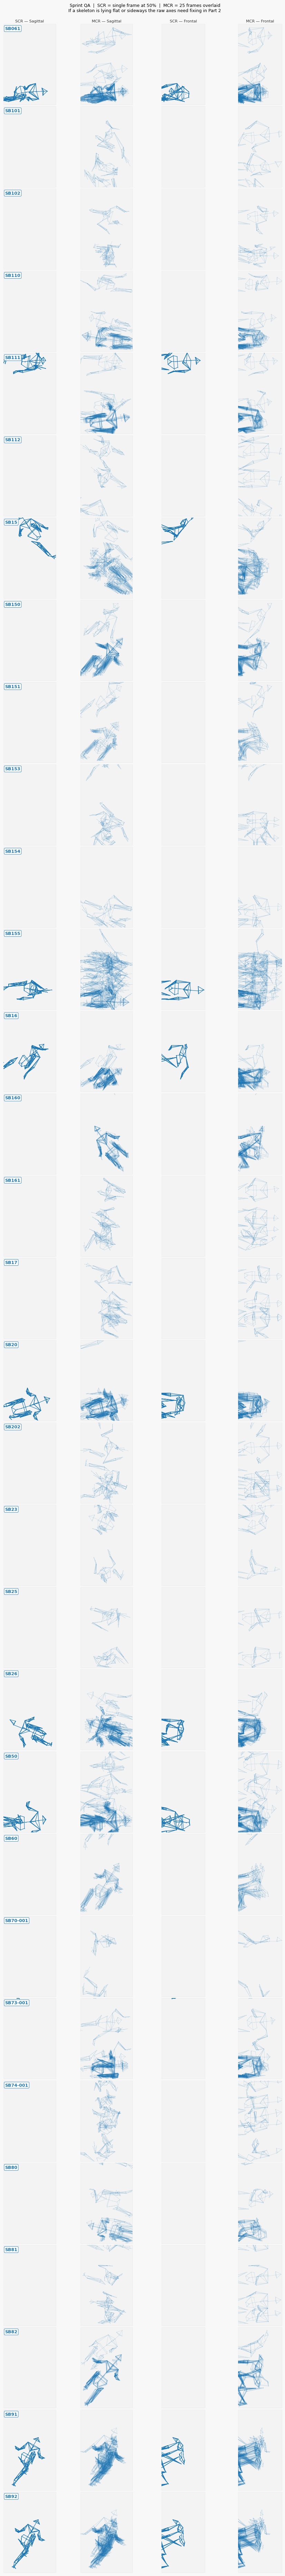

Saved : QA_skeleton_grid.png
Loaded: 31/31   |   Failed: 0


In [5]:
def _style_panel(ax, xlim, ylim):
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)


N_MCR       = 25
COL_HEADERS = ["SCR — Sagittal", "MCR — Sagittal", "SCR — Frontal", "MCR — Frontal"]
COL_PLANES  = ["sagittal",       "sagittal",        "frontal",       "frontal"]
COL_LIMITS  = [(AX_X, AX_Y),     (AX_X, AX_Y),      (AX_Z, AX_Y),    (AX_Z, AX_Y)]

all_names = os.listdir(C3D_DIR)
c3d_files = sorted([os.path.join(C3D_DIR, f) for f in all_names if f.endswith(".c3d")])
N = len(c3d_files)

if N == 0:
    print("No .c3d files found — check C3D_DIR in Cell 2.")
else:
    fig, axes = plt.subplots(N, 4, figsize=(4 * 2.4, N * 2.4), squeeze=False)
    fig.patch.set_facecolor("#f8f8f8")

    failed = []
    for i, fpath in enumerate(c3d_files):
        pid = os.path.splitext(os.path.basename(fpath))[0]
        print(f"[{i+1}/{N}] {pid}", end="\r")

        try:
            markers, fs = load_c3d_raw(fpath)
            mm = prepare_for_display(markers)
            n  = mm.shape[0]

            scr_frame  = int(n * 0.50)
            mcr_frames = np.linspace(0, n - 1, N_MCR).astype(int)

            for j, (plane, (xlim, ylim)) in enumerate(zip(COL_PLANES, COL_LIMITS)):
                ax = axes[i, j]
                ax.fill_between([xlim[0], xlim[1]], ylim[0], ylim[1],
                                color="#e8e8e8", zorder=0, alpha=0.5)

                if j % 2 == 0:                          # SCR
                    draw_skeleton(ax, mm, scr_frame, plane=plane)
                else:                                   # MCR overlay
                    for f in mcr_frames:
                        draw_skeleton(ax, mm, f, plane=plane,
                                      alpha=0.18, lw=0.6, ms=1.0)

                _style_panel(ax, xlim, ylim)
                if i == 0:
                    ax.set_title(COL_HEADERS[j], fontsize=8, pad=4, color="#333333")

            axes[i, 0].text(0.03, 0.97, pid,
                            transform=axes[i, 0].transAxes,
                            fontsize=9, fontweight="bold", color="#1f77b4",
                            ha="left", va="top",
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                                      edgecolor="#1f77b4", lw=0.7, alpha=0.95))

        except Exception as e:
            failed.append((pid, str(e)))
            for j, (xlim, ylim) in enumerate(COL_LIMITS):
                ax = axes[i, j]
                ax.fill_between([xlim[0], xlim[1]], ylim[0], ylim[1],
                                color="#ffe8e8", zorder=0, alpha=0.5)
                ax.text(0.5, 0.5, f"FAILED\n{e.__class__.__name__}",
                        ha="center", va="center", fontsize=7, color="red",
                        transform=ax.transAxes)
                _style_panel(ax, xlim, ylim)
            axes[i, 0].text(0.03, 0.97, pid,
                            transform=axes[i, 0].transAxes,
                            fontsize=9, fontweight="bold", color="red",
                            ha="left", va="top",
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                                      edgecolor="red", lw=0.7, alpha=0.95))

    print()
    fig.suptitle(
        "Sprint QA  |  SCR = single frame at 50%  |  MCR = 25 frames overlaid\n"
        "If a skeleton is lying flat or sideways the raw axes need fixing in Part 2",
        fontsize=9, y=1.001,
    )
    plt.tight_layout(pad=0.4, h_pad=0.3, w_pad=0.2)

    out_path = os.path.join(FIG_DIR, "QA_skeleton_grid.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved : {os.path.basename(out_path)}")
    print(f"Loaded: {N - len(failed)}/{N}   |   Failed: {len(failed)}")
    for pid, err in failed:
        print(f"  ✗ {pid}: {err}")

## PCA-Aligned Visualisation

Rotates every file into a consistent Global Coordinate System (X = forward, Y = up, Z = lateral)
using PCA on a single reference frame + centroid displacement for forward direction.
Based on Chris Velluci's `pca_xsens_align.m`.

In [6]:
def pca_align(markers):
    """Align markers to display GCS using Chris Velluci's approach.

    KEY INSIGHT: the raw Xsens C3D file is already gravity-aligned
    (the IMU suit measures gravity directly), so Z in the raw file IS vertical
    on every trial. Verified empirically: Z span ~2 m on all 31 files (runner
    height range), while X+Y combined spans 40-77 m (forward + lateral drift).
    Chris V. never re-derives vertical for this reason — only the horizontal
    travel direction needs to be found.

    Pipeline (mirrors Chris V. 01_Create_PCA_Matrix.m):
      1. Reset origin to the posterior heel at the first frame
         (Chris lines 46-57 — picks point 53 or 59, whichever is more posterior).
      2. Find travel direction in the horizontal X-Y plane via 2-D SVD on
         flattened marker data — total-least-squares equivalent of Chris's
         polyfit(x_all, y_all, 1), but symmetric in X and Y so it handles
         trials that ran along Y (e.g. SB60, SB91, SB92) just as cleanly.
      3. Rotate the horizontal plane so travel = display X.
      4. Sign-flip so +X is the direction of motion (centroid moves +X over time).
      5. Z is preserved unchanged → display Y (vertical).
         Horizontal residual → display Z (lateral).

    Output axes: X = forward, Y = up (gravity), Z = lateral.
    """
    n_frames = markers.shape[0]

    # ── 1. Posterior-heel origin reset (Chris lines 46-57) ───────────────────
    f0 = markers[0]
    heel_idx = R_HEEL if f0[R_HEEL, 0] < f0[L_HEEL, 0] else L_HEEL
    out = markers - f0[heel_idx]

    X, Y, Z = out[:, :, 0], out[:, :, 1], out[:, :, 2]

    # ── 2. Travel direction in horizontal plane (2-D SVD ≈ Chris's polyfit) ──
    xy   = np.column_stack([X.ravel(), Y.ravel()])
    xy_c = xy - xy.mean(axis=0)
    _, _, Vt = np.linalg.svd(xy_c, full_matrices=False)
    fwd  = Vt[0]                                # travel unit vector (2-D)
    lat  = np.array([-fwd[1], fwd[0]])          # 90° CCW = lateral

    # ── 3. Rotate horizontal plane ───────────────────────────────────────────
    new_X   = X * fwd[0] + Y * fwd[1]
    new_Lat = X * lat[0] + Y * lat[1]

    # ── 4. +X must point in the direction of motion ──────────────────────────
    centroid_fwd = new_X.mean(axis=1)
    if centroid_fwd[-1] < centroid_fwd[0]:
        new_X   = -new_X
        new_Lat = -new_Lat

    # ── 5. Stack as (forward, vertical, lateral) ─────────────────────────────
    return np.stack([new_X, Z, new_Lat], axis=-1)


# ── Sprint segmentation ──────────────────────────────────────────────────────

def segment_sprint(aligned, fs):
    """Trim trial from first movement (out of blocks) to ~62 m.
    Auto-detects sprint start via T12 X velocity threshold.
    Returns (trimmed, start_frame, end_frame).
    """
    t12_x = aligned[:, MK_T12, 0]
    vel_x = np.gradient(t12_x, 1.0 / fs)

    # smooth with 5-frame rolling mean
    kernel = np.ones(5) / 5.0
    vel_smooth = np.convolve(vel_x, kernel, mode='same')

    # find first frame where smoothed velocity > threshold for >= 3 consecutive
    above = vel_smooth > VEL_START_THRESH
    start_frame = 0
    for i in range(len(above) - 2):
        if above[i] and above[i + 1] and above[i + 2]:
            start_frame = max(0, i - 5)          # back up 5 frames for push-off
            break

    # crop at SPRINT_DIST_M forward distance
    distance = t12_x - t12_x[start_frame]
    end_candidates = np.where(distance > SPRINT_DIST_M)[0]
    end_frame = end_candidates[0] if len(end_candidates) > 0 else len(t12_x) - 1

    return aligned[start_frame:end_frame + 1], start_frame, end_frame


def compute_thoracic_velocity(aligned, fs):
    """Chris V.'s 7-marker thoracic centroid 3D velocity (m/s).
    Ref: 01_Create_PCA_Matrix.m lines 157-167.
    """
    dt = 1.0 / fs
    thor = aligned[:, THORAX_MKS, :].mean(axis=1)   # (n_frames, 3) centroid
    vx = np.gradient(thor[:, 0], dt)
    vy = np.gradient(thor[:, 1], dt)
    vz = np.gradient(thor[:, 2], dt)
    return np.sqrt(vx**2 + vy**2 + vz**2)


def find_max_velocity_phase(aligned, fs):
    """Find 5 strides at top speed (Chris V.'s method).
    Ref: 01_Create_PCA_Matrix.m lines 234-244.
    Returns dict: phase_start, phase_end, peak_frame, vel, cycle_indices.
    """
    vel = compute_thoracic_velocity(aligned, fs)
    margin = 10
    safe = vel[margin:-margin]
    peak_frame = int(np.argmax(safe)) + margin

    # R_HEEL ground contacts = local minima of Y = peaks of -Y
    r_heel_y = aligned[:, R_HEEL, 1]
    stride_peaks, _ = find_peaks(-r_heel_y, prominence=STRIDE_PROMINENCE)

    if len(stride_peaks) >= 6:
        closest_idx = int(np.argmin(np.abs(peak_frame - stride_peaks)))
        lo = max(closest_idx - 3, 0)
        hi = lo + 6
        if hi > len(stride_peaks):
            hi = len(stride_peaks)
            lo = max(hi - 6, 0)
        cycle_indices = stride_peaks[lo:hi]
        phase_start = cycle_indices[0]
        phase_end   = cycle_indices[-1]
    else:
        phase_start = max(0, peak_frame - 50)
        phase_end   = min(len(vel) - 1, peak_frame + 50)
        cycle_indices = np.array([phase_start, phase_end])

    return {
        'phase_start':   int(phase_start),
        'phase_end':     int(phase_end),
        'peak_frame':    int(peak_frame),
        'vel':           vel,
        'cycle_indices': cycle_indices,
    }


# ── Ground levelling — no-op (Z is already gravity-aligned) ──────────────────

def level_ground(aligned, phase_start, phase_end):
    """No-op: raw Xsens C3D Z axis is gravity-aligned, so the data is already
    level. Earlier rotational corrections (full-body polyfit, heel-contact
    polyfit) were trying to fix a tilt that PCA introduced by re-deriving
    vertical from variance. With Chris V.'s approach (raw Z = vertical),
    no rotation is needed. Kept here only for API compatibility with the
    pipeline cell. Args phase_start/phase_end are accepted but unused.
    """
    return aligned


def prepare_aligned(markers):
    """Per-frame ground offset + m → mm. Each frame's lowest foot marker → Y=0."""
    out = markers.copy()
    foot_min = out[:, FOOT_MKS, 1].min(axis=1, keepdims=True)  # (n_frames, 1)
    out[:, :, 1] -= foot_min
    return out * SCALE_MM


print("pca_align (Chris V. horizontal-plane only) + segment_sprint + "
      "compute_thoracic_velocity + find_max_velocity_phase + level_ground (no-op) + "
      "prepare_aligned defined.")


pca_align (Chris V. horizontal-plane only) + segment_sprint + compute_thoracic_velocity + find_max_velocity_phase + level_ground (no-op) + prepare_aligned defined.


[31/31] SB92  01  
All velocity checks passed.
Auto limits — sag H: (-1009, 934), frt H: (-676, 575), vert: (-174, 1959)


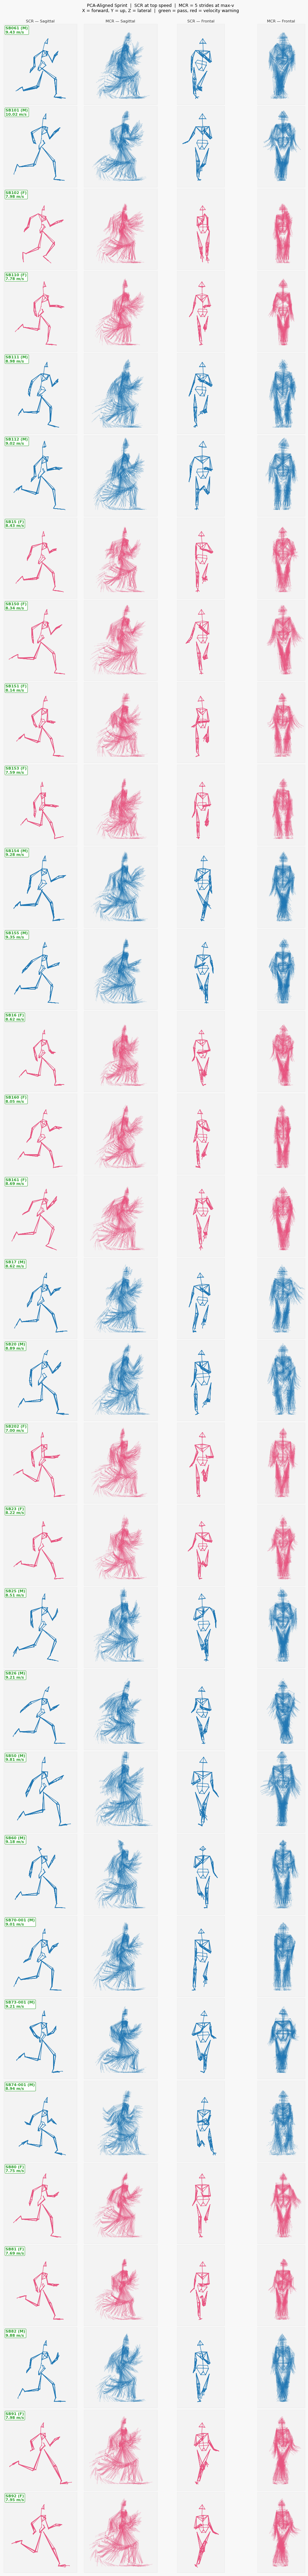

Saved : QA_skeleton_grid_top_speed.png
Aligned: 31/31   |   Failed: 0


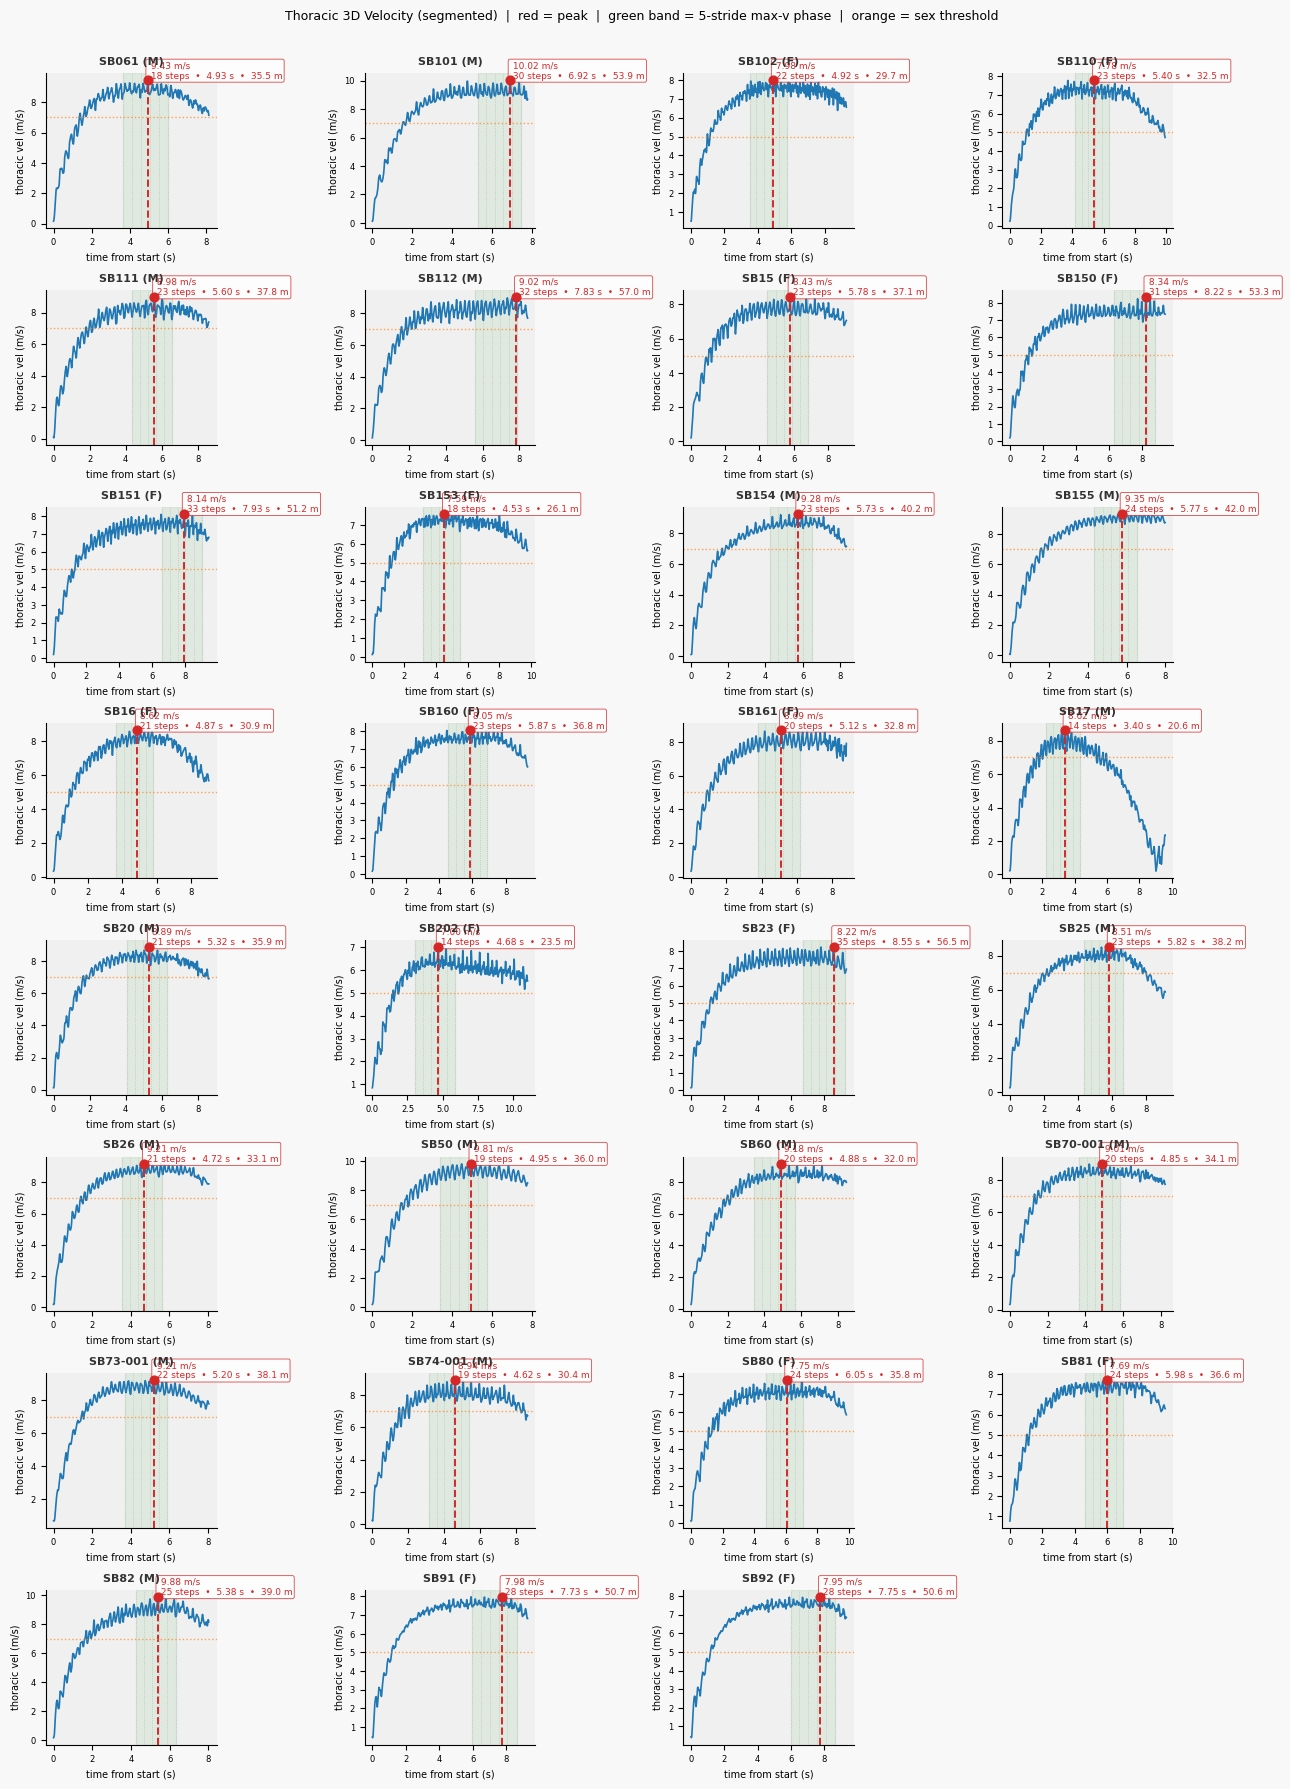

Saved : velocity_profiles_top_speed.png


In [7]:
# ── Pass 1: load → PCA → segment → max-v phase → level → prepare ─────────────
all_names = os.listdir(C3D_DIR)
c3d_files = sorted([os.path.join(C3D_DIR, f) for f in all_names if f.endswith(".c3d")])
N = len(c3d_files)

VEL_THRESH_M = 7.0
VEL_THRESH_F = 5.0

# Each entry: (pid, mm, scr_frame, mcr_frames, vel, phase_info, fs)
loaded       = []
failed_a     = []
loaded_extra = {}   # {pid: {n_steps, t_to_peak, dist_at_peak}}

for i, fpath in enumerate(c3d_files):
    pid = os.path.splitext(os.path.basename(fpath))[0]
    print(f"[{i+1}/{N}] {pid}  ", end="\r")
    try:
        markers, fs   = load_c3d_raw(fpath)
        aligned       = pca_align(markers)
        trimmed, s, e = segment_sprint(aligned, fs)
        phase         = find_max_velocity_phase(trimmed, fs)
        levelled      = level_ground(trimmed, phase['phase_start'], phase['phase_end'])
        mm            = prepare_aligned(levelled)

        scr_frame  = phase['peak_frame']
        mcr_frames = np.linspace(phase['phase_start'], phase['phase_end'],
                                 N_MCR).astype(int)

        loaded.append((pid, mm, scr_frame, mcr_frames, phase['vel'], phase, fs))

        # ── Annotation data: steps, time, and distance to peak velocity ─────
        pf_loc    = phase['peak_frame']
        _rp, _    = find_peaks(-trimmed[:, R_HEEL, 1], prominence=STRIDE_PROMINENCE)
        _lp, _    = find_peaks(-trimmed[:, L_HEEL, 1], prominence=STRIDE_PROMINENCE)
        _n_steps  = (sum(1 for c in _rp if c <= pf_loc) +
                     sum(1 for c in _lp if c <= pf_loc))
        loaded_extra[pid] = {
            'n_steps':      _n_steps,
            't_to_peak':    pf_loc / fs,
            'dist_at_peak': float(trimmed[pf_loc, MK_T12, 0] - trimmed[0, MK_T12, 0]),
        }
    except Exception as exc:
        loaded.append((pid, None, None, None, None, None, None))
        failed_a.append((pid, str(exc)))

# ── Sex-based velocity sanity check ───────────────────────────────────────────
vel_warnings = []
print()
for pid, mm, scr_frame, mcr_f, vel, phase, fs in loaded:
    if mm is None:
        continue
    sex = _get_sex(pid)
    peak_v = vel[phase['peak_frame']]
    thresh = VEL_THRESH_M if sex == 'M' else VEL_THRESH_F
    if peak_v < thresh:
        vel_warnings.append((pid, sex, peak_v, thresh))
    if peak_v < 0:
        vel_warnings.append((pid, sex, peak_v, 0.0))

if vel_warnings:
    print("Velocity warnings:")
    for pid, sex, pv, th in vel_warnings:
        print(f"  {pid} ({sex}): peak={pv:.2f} m/s  (threshold={th:.1f})")
else:
    print("All velocity checks passed.")

# ── Auto-scale axis limits from SCR frames ────────────────────────────────────
all_sag_h, all_frt_h, all_v = [], [], []
for pid, mm, scr_frame, mcr_f, vel, phase, fs in loaded:
    if mm is None:
        continue
    pts = mm[scr_frame].copy()
    all_sag_h.extend((pts[:, 0] - pts[MK_T12, 0]).tolist())
    all_frt_h.extend((pts[:, 2] - pts[MK_T12, 2]).tolist())
    all_v.extend(pts[:, 1].tolist())

PAD    = 150
AX_X_A = (min(all_sag_h) - PAD, max(all_sag_h) + PAD)
AX_Z_A = (min(all_frt_h) - PAD, max(all_frt_h) + PAD)
AX_Y_A = (min(all_v)     - PAD, max(all_v)     + PAD)

print(f"Auto limits — sag H: ({AX_X_A[0]:.0f}, {AX_X_A[1]:.0f}), "
      f"frt H: ({AX_Z_A[0]:.0f}, {AX_Z_A[1]:.0f}), "
      f"vert: ({AX_Y_A[0]:.0f}, {AX_Y_A[1]:.0f})")

# ── Pass 2: skeleton grid — SCR at top speed, MCR from max-v phase ───────────
COL_LIMITS_A = [(AX_X_A, AX_Y_A), (AX_X_A, AX_Y_A),
                (AX_Z_A, AX_Y_A), (AX_Z_A, AX_Y_A)]

fig2, axes2 = plt.subplots(N, 4, figsize=(4 * 2.4, N * 2.4), squeeze=False)
fig2.patch.set_facecolor("#f8f8f8")

for i, (pid, mm, scr_frame, mcr_f, vel, phase, fs) in enumerate(loaded):
    sex = _get_sex(pid)
    if mm is not None:
        top_speed = vel[phase['peak_frame']]
        thresh    = VEL_THRESH_M if sex == 'M' else VEL_THRESH_F
        ok        = top_speed >= thresh and top_speed > 0
        lbl_col   = "#2ca02c" if ok else "#d62728"
        sex_tag   = f" ({sex})" if sex != '?' else ""
        skel_col  = "#e75480" if sex == 'F' else "#1f77b4"  # pink=F, blue=M

        for j, (plane, (xlim, ylim)) in enumerate(zip(COL_PLANES, COL_LIMITS_A)):
            ax = axes2[i, j]
            ax.fill_between([xlim[0], xlim[1]], ylim[0], ylim[1],
                            color="#e8e8e8", zorder=0, alpha=0.5)
            if j % 2 == 0:                        # SCR at top speed
                draw_skeleton(ax, mm, scr_frame, plane=plane, color=skel_col)
            else:                                 # MCR from max-v phase
                for f in mcr_f:
                    draw_skeleton(ax, mm, f, plane=plane,
                                  alpha=0.18, lw=0.6, ms=1.0, color=skel_col)
            _style_panel(ax, xlim, ylim)
            if i == 0:
                ax.set_title(COL_HEADERS[j], fontsize=8, pad=4, color="#333333")

        label = f"{pid}{sex_tag}\n{top_speed:.2f} m/s"
        axes2[i, 0].text(0.03, 0.97, label,
                         transform=axes2[i, 0].transAxes,
                         fontsize=8, fontweight="bold", color=lbl_col,
                         ha="left", va="top",
                         bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                                   edgecolor=lbl_col, lw=0.7, alpha=0.95))
    else:
        for j, (xlim, ylim) in enumerate(COL_LIMITS_A):
            ax = axes2[i, j]
            ax.fill_between([xlim[0], xlim[1]], ylim[0], ylim[1],
                            color="#ffe8e8", zorder=0, alpha=0.5)
            ax.text(0.5, 0.5, "FAILED", ha="center", va="center",
                    fontsize=7, color="red", transform=ax.transAxes)
            _style_panel(ax, xlim, ylim)
        axes2[i, 0].text(0.03, 0.97, pid,
                         transform=axes2[i, 0].transAxes,
                         fontsize=9, fontweight="bold", color="red",
                         ha="left", va="top",
                         bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                                   edgecolor="red", lw=0.7, alpha=0.95))

fig2.suptitle(
    "PCA-Aligned Sprint  |  SCR at top speed  |  MCR = 5 strides at max-v\n"
    "X = forward, Y = up, Z = lateral  |  green = pass, red = velocity warning",
    fontsize=9, y=1.001,
)
plt.tight_layout(pad=0.4, h_pad=0.3, w_pad=0.2)

out_path2 = os.path.join(FIG_DIR, "QA_skeleton_grid_top_speed.png")
fig2.savefig(out_path2, dpi=150, bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()
print(f"Saved : {os.path.basename(out_path2)}")
print(f"Aligned: {N - len(failed_a)}/{N}   |   Failed: {len(failed_a)}")
for pid, err in failed_a:
    print(f"  x {pid}: {err}")

# ── Pass 3: segmented velocity profiles with stride boundaries ────────────────
n_ok     = sum(1 for _, mm, *_ in loaded if mm is not None)
n_cols_v = min(4, n_ok)
n_rows_v = int(np.ceil(n_ok / n_cols_v))

fig3, axes3 = plt.subplots(n_rows_v, n_cols_v,
                            figsize=(n_cols_v * 3.2, n_rows_v * 2.2),
                            squeeze=False)
fig3.patch.set_facecolor("#f8f8f8")

plot_idx = 0
for pid, mm, scr_frame, mcr_f, vel, phase, fs in loaded:
    if mm is None:
        continue
    sex = _get_sex(pid)
    r, c_idx = divmod(plot_idx, n_cols_v)
    ax   = axes3[r, c_idx]
    t    = np.arange(len(vel)) / fs              # time from sprint start
    thresh = VEL_THRESH_M if sex == 'M' else VEL_THRESH_F
    pf   = phase['peak_frame']

    ax.plot(t, vel, color="#1f77b4", lw=1.2)
    ax.axvline(pf / fs, color="#d62728", lw=1.4, ls="--")
    ax.scatter([pf / fs], [vel[pf]], color="#d62728", s=40, zorder=5)
    _ex  = loaded_extra.get(pid, {})
    _ns  = _ex.get('n_steps')
    _tt  = _ex.get('t_to_peak', pf / fs)
    _dm  = _ex.get('dist_at_peak')
    _ann = (f" {vel[pf]:.2f} m/s"
            + (f"\n {_ns} steps" if _ns is not None else "")
            + f"  \u2022  {_tt:.2f} s"
            + (f"  \u2022  {_dm:.1f} m" if _dm is not None else ""))
    ax.text(pf / fs, vel[pf], _ann, fontsize=6.5, color="#d62728", va="bottom",
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='#d62728', lw=0.6, alpha=0.85))

    # stride boundaries as grey verticals
    for ci in phase['cycle_indices']:
        ax.axvline(ci / fs, color="#999999", lw=0.6, ls=":", alpha=0.5)

    # max-v phase shading
    ax.axvspan(phase['phase_start'] / fs, phase['phase_end'] / fs,
               color="#2ca02c", alpha=0.08)

    # threshold line
    ax.axhline(thresh, color="#ff7f0e", lw=1.0, ls=":", alpha=0.7)

    sex_tag = f" ({sex})" if sex != '?' else ""
    ax.set_title(f"{pid}{sex_tag}", fontsize=8, fontweight="bold", color="#333333")
    ax.set_xlabel("time from start (s)", fontsize=7)
    ax.set_ylabel("thoracic vel (m/s)", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_facecolor("#f0f0f0")

    plot_idx += 1

for k in range(plot_idx, n_rows_v * n_cols_v):
    r, c_idx = divmod(k, n_cols_v)
    axes3[r, c_idx].set_visible(False)

fig3.suptitle(
    "Thoracic 3D Velocity (segmented)  |  red = peak  |  "
    "green band = 5-stride max-v phase  |  orange = sex threshold",
    fontsize=9, y=1.01)
plt.tight_layout(pad=0.6, h_pad=0.8, w_pad=0.5)

out_path3 = os.path.join(FIG_DIR, "velocity_profiles_top_speed.png")
fig3.savefig(out_path3, dpi=150, bbox_inches="tight", facecolor=fig3.get_facecolor())
plt.show()
print(f"Saved : {os.path.basename(out_path3)}")